# t-SNE Visualization of CPD Component Loadings

## Goal

After CPD decomposition, each video is represented by a vector of component loadings (the row of the U matrix).

This notebook uses **t-SNE** to visualize these high-dimensional embeddings in 2D to answer:

1. **Do videos from the same crossing cluster together?** -> Crossing-specific patterns
2. **Do videos from the same time-of-day cluster together?** -> Temporal patterns
3. **Are there distinct clusters?** -> CPD found meaningful structure

---

## Approach

For both **Standard CPD** and **Non-Negative CPD** at rank 4:

1. Extract U matrix (31 videos × 4 components)
2. Apply t-SNE: 4D -> 2D
3. Plot with colors:
   - By crossing location
   - By time-of-day
4. Compare standard vs non-negative CPD

In [1]:
# Setup
import sys
sys.path.append('../src')  # For tensor module

import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from pathlib import Path

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

# Paths
DATA_DIR = Path('../data')
RESULTS_PATH = DATA_DIR / 'cpd_results_31videos.pkl'

print("Libraries loaded")

Libraries loaded


## Load CPD Results

In [2]:
# Load pre-computed CPD results from video_level_analysis.ipynb
with open(RESULTS_PATH, 'rb') as f:
    data = pickle.load(f)

results = data['results']  # Standard CPD
video_metadata = data['video_metadata']
tensor = data['tensor']

print(f"Loaded CPD results for {len(video_metadata)} videos")
print(f"Available ranks: {list(results.keys())}")
print(f"\nTensor shape: {tensor.shape}")

Loaded CPD results for 31 videos
Available ranks: [2, 3, 4]

Tensor shape: (3, 31, 31)


In [3]:
# Load non-negative CPD results from separate file
RESULTS_NN_PATH = DATA_DIR / 'cpd_results_nonnegative_31videos.pkl'

if RESULTS_NN_PATH.exists():
    with open(RESULTS_NN_PATH, 'rb') as f:
        data_nn = pickle.load(f)
    results_nn = data_nn['results_nn']
    print(f"Non-negative CPD results loaded")
    print(f"  Available ranks: {list(results_nn.keys())}")
    HAS_NONNEG = True
else:
    print("Non-negative CPD results not found")
    print(f"   Expected path: {RESULTS_NN_PATH}")
    print("   Re-run video_level_analysis.ipynb to generate them")
    HAS_NONNEG = False

Non-negative CPD results loaded
  Available ranks: [2, 3, 4]


## Extract Component Loadings (U matrix)

Each video is represented by its loadings on the 4 components.

In [4]:
# Use rank 4 as recommended by PI
rank = 4

# Extract U matrices
U_standard = results[rank]['U']  # (31 videos × 4 components)

print(f"Standard CPD U matrix shape: {U_standard.shape}")
print(f"\nEach row = 4D embedding for one video")
print(f"We'll use t-SNE to visualize these 31 points in 2D")

if HAS_NONNEG:
    # Check if rank 4 is available for non-negative
    if rank in results_nn:
        U_nonneg = results_nn[rank]['U']
        print(f"\nNon-negative CPD U matrix shape: {U_nonneg.shape}")
    else:
        print(f"\nRank {rank} not available in non-negative CPD")
        print(f"   Available ranks: {list(results_nn.keys())}")
        print(f"   Re-run video_level_analysis.ipynb cell 32 to generate rank 4")
        HAS_NONNEG = False

Standard CPD U matrix shape: (31, 4)

Each row = 4D embedding for one video
We'll use t-SNE to visualize these 31 points in 2D

Non-negative CPD U matrix shape: (31, 4)


## Create Label Arrays for Coloring

In [5]:
# Extract labels from metadata
time_labels = [v['time_of_day'] for v in video_metadata]
crossing_labels = [v['crossing'] for v in video_metadata]

# Create color maps
time_color_map = {
    'off_peak': '#2C3E50',
    'morning_rush': '#E74C3C',
    'midday': '#F39C12',
    'afternoon_evening': '#8E44AD'
}

crossing_color_map = {
    '35th and Cornhusker Hwy': '#3498DB',
    '27th and NE Pkwy': '#2ECC71',
    '56 & Old Cheney': '#E67E22',
    'NW 12th & Cornhusker': '#9B59B6'
}

time_colors = [time_color_map[t] for t in time_labels]
crossing_colors = [crossing_color_map[c] for c in crossing_labels]

# Create readable labels for legend
time_labels_readable = {
    'off_peak': 'Off-Peak (7PM-6AM)',
    'morning_rush': 'Morning Rush (6AM-10AM)',
    'midday': 'Midday (10AM-3PM)',
    'afternoon_evening': 'Afternoon/Evening (3PM-7PM)'
}

crossing_labels_readable = {
    '35th and Cornhusker Hwy': '35th & Cornhusker',
    '27th and NE Pkwy': '27th & NE Pkwy',
    '56 & Old Cheney': '56 & Old Cheney',
    'NW 12th & Cornhusker': 'NW 12th & Cornhusker'
}

print("Labels and colors prepared")
print(f"\nTime-of-day distribution:")
from collections import Counter
for time, count in Counter(time_labels).items():
    print(f"  {time_labels_readable[time]:30s}: {count:2d} videos")

print(f"\nCrossing distribution:")
for crossing, count in Counter(crossing_labels).items():
    print(f"  {crossing_labels_readable[crossing]:30s}: {count:2d} videos")

Labels and colors prepared

Time-of-day distribution:
  Off-Peak (7PM-6AM)            : 12 videos
  Afternoon/Evening (3PM-7PM)   :  2 videos
  Morning Rush (6AM-10AM)       :  9 videos
  Midday (10AM-3PM)             :  8 videos

Crossing distribution:
  27th & NE Pkwy                :  1 videos
  35th & Cornhusker             : 23 videos
  56 & Old Cheney               :  1 videos
  NW 12th & Cornhusker          :  6 videos


## Apply t-SNE: 4D -> 2D

t-SNE (t-Distributed Stochastic Neighbor Embedding) is a dimensionality reduction technique that:
- Preserves local structure (similar points stay close)
- Creates clear clusters if they exist
- Maps high-dimensional data to 2D for visualization

In [6]:
# Set random seed for reproducibility
RANDOM_SEED = 42

# t-SNE parameters
tsne_params = {
    'n_components': 2,
    'perplexity': 5,  # Small dataset (31 points), use small perplexity
    'random_state': RANDOM_SEED,
    'n_iter': 1000,
    'learning_rate': 200.0
}

print(f"Running t-SNE with parameters:")
for key, val in tsne_params.items():
    print(f"  {key}: {val}")

# Apply t-SNE to standard CPD
print(f"\nApplying t-SNE to Standard CPD...")
tsne = TSNE(**tsne_params)
U_standard_2d = tsne.fit_transform(U_standard)
print(f"Standard CPD: {U_standard.shape} -> {U_standard_2d.shape}")

# Apply t-SNE to non-negative CPD if available
if HAS_NONNEG:
    print(f"\nApplying t-SNE to Non-Negative CPD...")
    tsne_nn = TSNE(**tsne_params)
    U_nonneg_2d = tsne_nn.fit_transform(U_nonneg)
    print(f"Non-negative CPD: {U_nonneg.shape} -> {U_nonneg_2d.shape}")

Running t-SNE with parameters:
  n_components: 2
  perplexity: 5
  random_state: 42
  n_iter: 1000
  learning_rate: 200.0

Applying t-SNE to Standard CPD...


Standard CPD: (31, 4) -> (31, 2)

Applying t-SNE to Non-Negative CPD...
Non-negative CPD: (31, 4) -> (31, 2)


## Visualization: Standard CPD

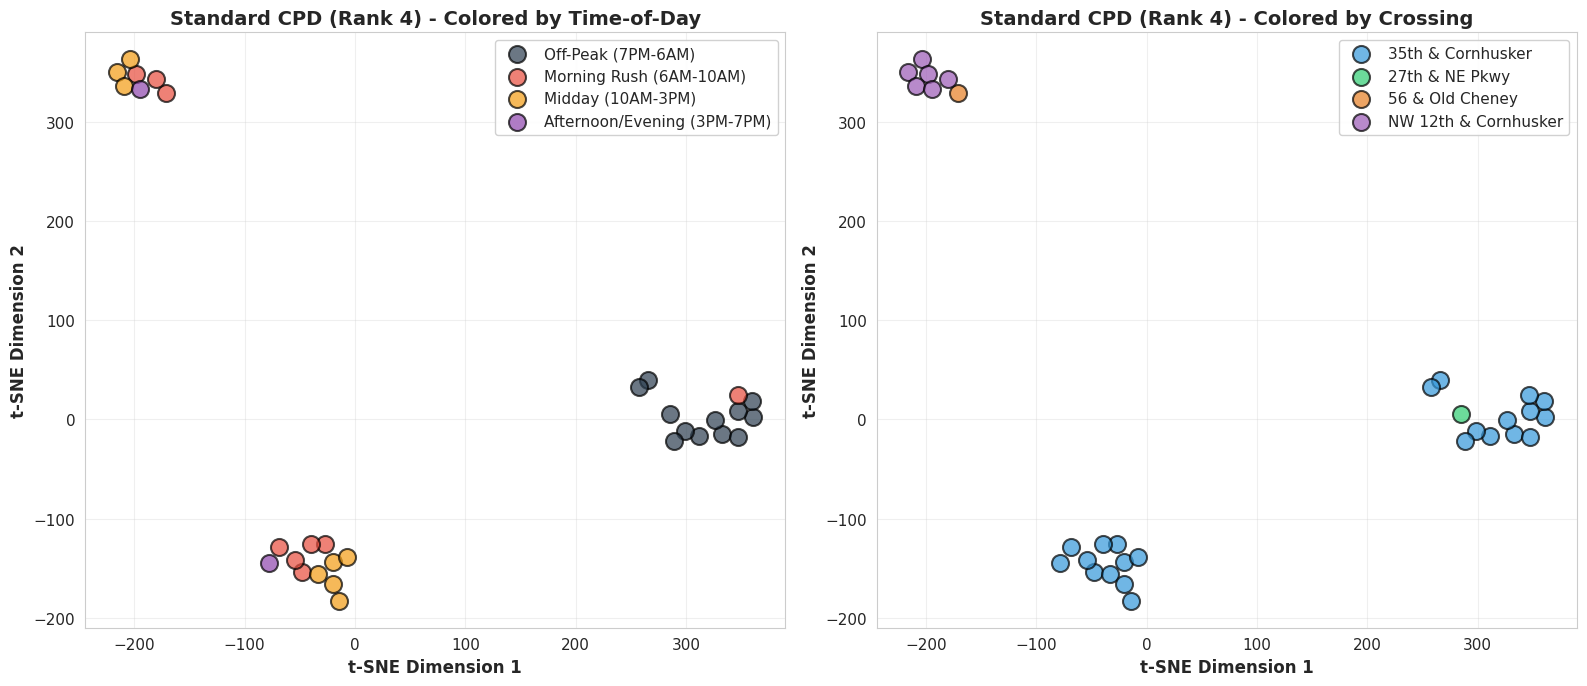


Saved: data/tsne_standard_cpd_rank4.png


In [7]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Panel 1: Colored by Time-of-Day
ax1 = axes[0]
for time_label in time_color_map.keys():
    mask = np.array(time_labels) == time_label
    ax1.scatter(
        U_standard_2d[mask, 0], 
        U_standard_2d[mask, 1],
        c=time_color_map[time_label],
        label=time_labels_readable[time_label],
        s=150,
        alpha=0.7,
        edgecolors='black',
        linewidths=1.5
    )

ax1.set_xlabel('t-SNE Dimension 1', fontweight='bold', fontsize=12)
ax1.set_ylabel('t-SNE Dimension 2', fontweight='bold', fontsize=12)
ax1.set_title('Standard CPD (Rank 4) - Colored by Time-of-Day', fontweight='bold', fontsize=14)
ax1.legend(loc='best', framealpha=0.9)
ax1.grid(True, alpha=0.3)

# Panel 2: Colored by Crossing
ax2 = axes[1]
for crossing_label in crossing_color_map.keys():
    mask = np.array(crossing_labels) == crossing_label
    ax2.scatter(
        U_standard_2d[mask, 0], 
        U_standard_2d[mask, 1],
        c=crossing_color_map[crossing_label],
        label=crossing_labels_readable[crossing_label],
        s=150,
        alpha=0.7,
        edgecolors='black',
        linewidths=1.5
    )

ax2.set_xlabel('t-SNE Dimension 1', fontweight='bold', fontsize=12)
ax2.set_ylabel('t-SNE Dimension 2', fontweight='bold', fontsize=12)
ax2.set_title('Standard CPD (Rank 4) - Colored by Crossing', fontweight='bold', fontsize=14)
ax2.legend(loc='best', framealpha=0.9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / 'tsne_standard_cpd_rank4.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSaved: data/tsne_standard_cpd_rank4.png")

## Visualization: Non-Negative CPD (if available)

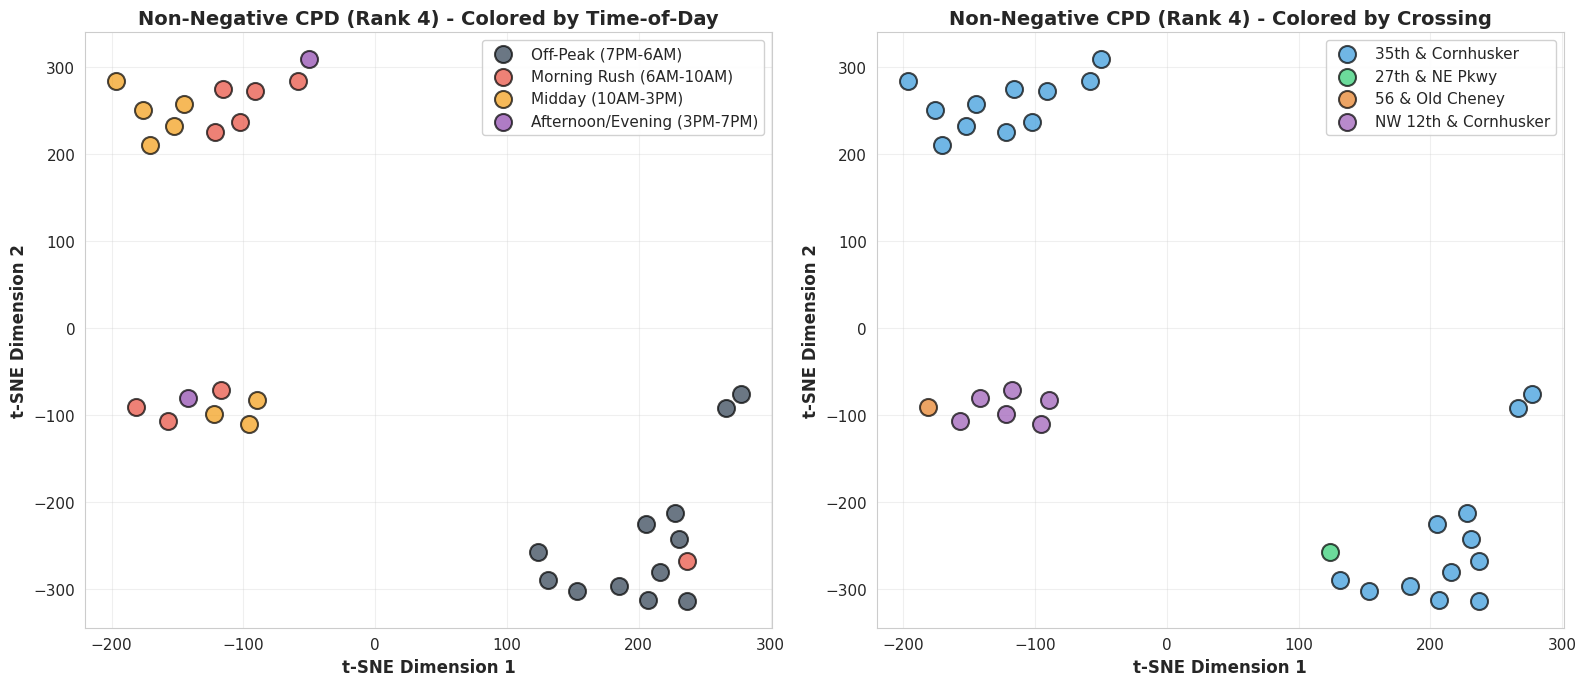


Saved: data/tsne_nonnegative_cpd_rank4.png


In [8]:
if HAS_NONNEG:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Panel 1: Colored by Time-of-Day
    ax1 = axes[0]
    for time_label in time_color_map.keys():
        mask = np.array(time_labels) == time_label
        ax1.scatter(
            U_nonneg_2d[mask, 0], 
            U_nonneg_2d[mask, 1],
            c=time_color_map[time_label],
            label=time_labels_readable[time_label],
            s=150,
            alpha=0.7,
            edgecolors='black',
            linewidths=1.5
        )

    ax1.set_xlabel('t-SNE Dimension 1', fontweight='bold', fontsize=12)
    ax1.set_ylabel('t-SNE Dimension 2', fontweight='bold', fontsize=12)
    ax1.set_title('Non-Negative CPD (Rank 4) - Colored by Time-of-Day', fontweight='bold', fontsize=14)
    ax1.legend(loc='best', framealpha=0.9)
    ax1.grid(True, alpha=0.3)

    # Panel 2: Colored by Crossing
    ax2 = axes[1]
    for crossing_label in crossing_color_map.keys():
        mask = np.array(crossing_labels) == crossing_label
        ax2.scatter(
            U_nonneg_2d[mask, 0], 
            U_nonneg_2d[mask, 1],
            c=crossing_color_map[crossing_label],
            label=crossing_labels_readable[crossing_label],
            s=150,
            alpha=0.7,
            edgecolors='black',
            linewidths=1.5
        )

    ax2.set_xlabel('t-SNE Dimension 1', fontweight='bold', fontsize=12)
    ax2.set_ylabel('t-SNE Dimension 2', fontweight='bold', fontsize=12)
    ax2.set_title('Non-Negative CPD (Rank 4) - Colored by Crossing', fontweight='bold', fontsize=14)
    ax2.legend(loc='best', framealpha=0.9)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(DATA_DIR / 'tsne_nonnegative_cpd_rank4.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\nSaved: data/tsne_nonnegative_cpd_rank4.png")
else:
    print("Skipping non-negative CPD visualization (results not available)")

## Interpretation Questions

Look at the t-SNE plots and ask:

### 1. Crossing Patterns
- **Do NW 12th videos (purple) cluster together?**
  - If YES -> NW 12th has unique behavioral patterns
  - If NO -> Crossing location doesn't strongly affect behavior

- **Do 35th Cornhusker videos (blue, 23 videos) spread out or cluster?**
  - Spread -> High variability within one crossing (likely time-of-day effects)
  - Cluster -> Consistent crossing-specific behavior

### 2. Time-of-Day Patterns
- **Do morning rush videos (red) cluster together?**
  - If YES -> Time-of-day is a dominant factor
  - If NO -> Crossing-specific effects dominate over time

- **Are off-peak videos (dark blue, 12 videos) separate from daytime?**
  - Could indicate nighttime behavioral differences

### 3. Overall Structure
- **Are there distinct clusters or gradual transitions?**
  - Distinct clusters -> Clear behavioral categories
  - Gradual -> Behavior varies smoothly along some dimension

### 4. Outliers
- **Are there isolated points?**
  - These videos have unique behavioral signatures
  - Worth investigating for potential safety concerns

## Identify Outliers

Find videos that are far from their cluster centers.

In [9]:
# Calculate distance from centroid for each crossing group
print("Potential outliers (videos far from their crossing's centroid):")
print("="*70)

for crossing_label in crossing_color_map.keys():
    # Get videos for this crossing
    mask = np.array(crossing_labels) == crossing_label
    crossing_points = U_standard_2d[mask]
    
    if len(crossing_points) < 2:
        continue
    
    # Calculate centroid
    centroid = crossing_points.mean(axis=0)
    
    # Calculate distances
    distances = np.sqrt(((crossing_points - centroid) ** 2).sum(axis=1))
    
    # Get video indices for this crossing
    video_indices = np.where(mask)[0]
    
    # Find furthest video
    furthest_idx = distances.argmax()
    furthest_video_idx = video_indices[furthest_idx]
    furthest_video = video_metadata[furthest_video_idx]
    
    print(f"\n{crossing_labels_readable[crossing_label]}:")
    print(f"  Furthest video: [{furthest_video['time_of_day']:20s}] {furthest_video['filename'][:40]}")
    print(f"  Distance from centroid: {distances[furthest_idx]:.3f}")
    print(f"  Mean distance: {distances.mean():.3f}")

print("\n" + "="*70)

Potential outliers (videos far from their crossing's centroid):

35th & Cornhusker:
  Furthest video: [afternoon_evening   ] 2024-02-10_03-20-23 - Trim 1.mp4
  Distance from centroid: 240.051
  Mean distance: 194.973

NW 12th & Cornhusker:
  Furthest video: [morning_rush        ] 2024-02-14_14-58-11 - Trim 1.mp4
  Distance from centroid: 20.233
  Mean distance: 13.934



## Summary

This notebook visualized the CPD component loadings using t-SNE to reveal:

- Whether videos cluster by **crossing location**  
- Whether videos cluster by **time-of-day**  
- Which videos are **outliers** (far from their group)  
- Overall **structure** in the behavioral patterns  

The t-SNE plots help interpret what the CPD components captured!